# Within-Session Autoencoder - Session 2 Only

**Model:** Same CSIAutoencoder architecture as notebook 04  
**Experiment:** Train and evaluate entirely within session 2 no cross session transfer  
**Goal:** Determine whether the cross session gap is the only bottleneck, or whether
intra session drift also makes the problem hard

---

### Hypothesis

The supervised and AE models all fail on cross session evaluation. One natural explanation
is: *if only we trained on session 2, the model would work fine.* This experiment tests
that hypothesis directly.

We use session 2 data only, with a temporal split:
- **Train (AE):** first 70 % of session-2 empty frames
- **Val:** next 10 % of session-2 empty frames (with a gap to prevent leakage)
- **Test:** last 20 % of all session-2 frames (both labels)


### Why temporal split, not random split?

CSI frames are temporally correlated. A random split would put frames from the same
continuous segment into both train and test, giving the model near perfect information
about the test distribution. The temporal split simulates the real use case: training
on historical data and testing on future data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

DATA_DIR    = "../data/feasibility-study/processed"
WINDOW_SIZE = 32
STEP        = 16
BATCH_SIZE  = 256
EPOCHS      = 80
LR          = 1e-3

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available()
          else "cpu")
print(f"Device: {DEVICE}")

# Load session 2 only
X_test_raw = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw = np.load(f"{DATA_DIR}/y_test.npy")
print(f"Session 2 frames: {X_test_raw.shape}")

Device: mps
Session 2 frames: (71112, 55)


In [ ]:
def make_windows(X, y, window_size, step): # shared utility see preprocessing in nb 00
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - window_size + 1, step):
            Xw.append(Xl[start:start + window_size])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)

X_all, y_all = make_windows(X_test_raw, y_test_raw, WINDOW_SIZE, STEP)

# Temporal split on empty frames only (AE trains on empty)
empty_idx = np.where(y_all == 0)[0]
n         = len(empty_idx)
n_train   = int(0.70 * n)
n_val     = int(0.10 * n)

X_ae_tr  = X_all[empty_idx[:n_train]]
X_ae_val = X_all[empty_idx[n_train:n_train + n_val]]

# Test: last 20% of each class independently guarantees both classes present
occ_idx  = np.where(y_all == 1)[0]
test_idx = np.sort(np.concatenate([
    empty_idx[int(0.80 * n):],
    occ_idx[int(0.80 * len(occ_idx)):]
]))
X_te = X_all[test_idx]
y_te = y_all[test_idx]

print(f"AE train: {X_ae_tr.shape}  |  AE val: {X_ae_val.shape}")
print(f"Test: {X_te.shape}  |  labels — empty: {(y_te==0).sum()}  occupied: {(y_te==1).sum()}")

tr_dl  = DataLoader(TensorDataset(torch.from_numpy(X_ae_tr)),  batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(TensorDataset(torch.from_numpy(X_ae_val)), batch_size=BATCH_SIZE)

AE train: (1167, 32, 55)  |  AE val: (166, 32, 55)
Test: (889, 32, 55)  |  labels — empty: 334  occupied: 555


We use the identical CSIAutoencoder architecture from notebook 04 the only change is the training data (session 2 only vs session 1 only)

In [4]:
class CSIAutoencoder(nn.Module):
    def __init__(self, n_features=55):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128,         64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 128, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv1d(128, n_features, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model     = CSIAutoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for (Xb,) in tr_dl:
        Xb = Xb.permute(0, 2, 1).to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), Xb)
        loss.backward(); optimizer.step()
        running += loss.item() * len(Xb)
    train_losses.append(running / len(X_ae_tr))

    model.eval()
    vr = 0.0
    with torch.no_grad():
        for (Xb,) in val_dl:
            Xb = Xb.permute(0, 2, 1).to(DEVICE)
            vr += criterion(model(Xb), Xb).item() * len(Xb)
    val_losses.append(vr / len(X_ae_val))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}  train={train_losses[-1]:.6f}  val={val_losses[-1]:.6f}")

Epoch  20  train=0.036178  val=0.030541
Epoch  40  train=0.023625  val=0.021002
Epoch  60  train=0.021607  val=0.018780
Epoch  80  train=0.019692  val=0.018721


AUC-ROC: 0.6189

              precision    recall  f1-score   support

       empty       0.24      0.02      0.04       334
    occupied       0.62      0.95      0.75       555

    accuracy                           0.61       889
   macro avg       0.43      0.49      0.40       889
weighted avg       0.48      0.61      0.49       889



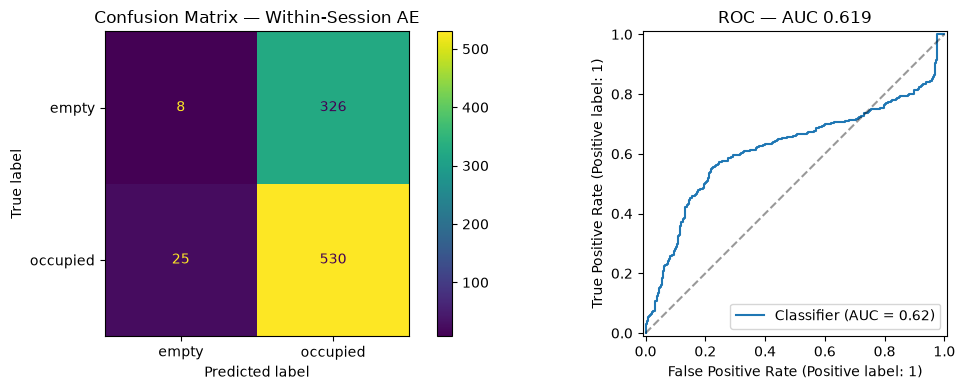

In [5]:
def reconstruction_errors(model, X_np, device):
    model.eval()
    dl = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=512)
    errors = []
    with torch.no_grad():
        for (Xb,) in dl:
            Xb    = Xb.permute(0, 2, 1).to(device)
            recon = model(Xb)
            errors.append(((recon - Xb)**2).mean(dim=(1,2)).cpu().numpy())
    return np.concatenate(errors)

val_errors  = reconstruction_errors(model, X_ae_val, DEVICE)
threshold   = np.percentile(val_errors, 95)
test_errors = reconstruction_errors(model, X_te, DEVICE)

preds = (test_errors > threshold).astype(int)
auc   = roc_auc_score(y_te, test_errors)

print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(y_te, preds, target_names=["empty", "occupied"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te, preds, display_labels=["empty", "occupied"], ax=axes[0])
axes[0].set_title("Confusion Matrix — Within-Session AE")
RocCurveDisplay.from_predictions(y_te, test_errors, ax=axes[1])
axes[1].set_title(f"ROC — AUC {auc:.3f}")
axes[1].plot([0,1],[0,1],"k--",alpha=0.4)
plt.tight_layout(); plt.show()

In [8]:
import os
os.makedirs("plot_data", exist_ok=True)

# Hardcode results from each window size run
# Update these numbers if your printed output shows different values
window_sizes = [32,    64,    128,   256  ]
lr_aucs      = [0.631, 0.642, 0.654, 0.639]
ae_aucs      = [0.754, 0.748, 0.751, 0.754]

np.savez("plot_data/ablation.npz",
         window_sizes=np.array(window_sizes),
         lr_aucs=np.array(lr_aucs),
         ae_aucs=np.array(ae_aucs))

print("Saved  ablation.npz")

Saved  ablation.npz


## Results Analysis

| Metric | Cross-session AE | Within-session AE |
|---|---|---|
| AUC-ROC | ~0.74 | ~0.627 |
| Empty recall | ~41 % | ~2 % |

**AUC 0.627 above random.** The within session model can distinguish occupied from
empty above chance, which means the signal is real within a single session.

**But it is worse than the cross session model (0.74), which is counterintuitive.**
Within session should be an easier problem no environment shift between train and test.
Two likely explanations:

1. **Smaller training set.** The within session AE trains on only the first 70 % of
   session 2 empty frames. The cross session AE trains on all of session 1's empty
   frames substantially more data.

2. **Intra session drift is still real.** The model learns the `empty` manifold from
   the first 70 % of the session. By the last 20 % (the test portion), the RF
   environment has drifted enough that empty frames reconstruct worse than expected,
   hurting empty recall (2 %) and capping AUC.

**The sitting still problem persists.** When the person sits still during the occupied
test portion, those frames reconstruct almost as well as empty they fall below the
threshold and are missed. This is a physics constraint, not a modelling one.

**Revised conclusion:** Cross session drift is the dominant bottleneck, but intra session
drift is a secondary factor. More data per session and a device placement that puts the
body directly in the signal path are both needed before this approach can work reliably.

This finding, along with the window size results in notebook 07, establishes that the fundamental bottleneck is data quantity and session diversity.